In [3]:
# If needed once in this environment:
# %pip install python-dotenv sqlalchemy pyodbc pandas numpy scikit-learn lifelines

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from lifelines import CoxPHFitter
except ImportError:
    CoxPHFitter = None

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table

In [4]:
# Paths
project_root = Path.cwd().resolve().parent  # .../yieldCurve_augmenting
env_path = project_root / '.env'
sql_path = project_root / 'sql_scripts' / 'jcx_raw_harvey_v11.sql'

# Load SQL and execute temp-table workflow
engine = create_db_engine(env_path)
setup_sql = read_sql_file(sql_path)

raw_df = execute_sql_and_read_temp_table(engine, setup_sql, '#t17_mfg')

print('SQL loaded from:', sql_path)
print('Using env file:', env_path)
print('raw_df shape:', raw_df.shape)
raw_df.head()

SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_raw_harvey_v11.sql
Using env file: /Users/starsrain/2025_concord/yieldCurve_augmenting/.env
raw_df shape: (1006810, 31)


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,isRecentLoan,...,TotalRealizedPayment,AppYear,AppMonth,AppWeek,LoanStatus,CustType,Frequency,OriginatedAmount,OriginationDate,InstallmentNumberMFG
0,104253709,5,I1530087-0,5,600.0,779,144,19,2023-05-31,0,...,6225.0,2023,1,1,D,RETURN,M,1000.0,2023-01-03,5
1,104253709,5,I1530087-0,6,550.0,111,144,19,2023-06-30,0,...,6225.0,2023,1,1,D,RETURN,M,1000.0,2023-01-03,6
2,104253709,5,I1530087-0,7,500.0,111,144,19,2023-07-31,0,...,6225.0,2023,1,1,D,RETURN,M,1000.0,2023-01-03,7
3,104253709,5,I1530087-0,8,450.0,111,144,19,2023-08-31,0,...,6225.0,2023,1,1,D,RETURN,M,1000.0,2023-01-03,8
4,104253709,5,I1530087-0,9,400.0,111,144,19,2023-09-29,0,...,6225.0,2023,1,1,D,RETURN,M,1000.0,2023-01-03,9


In [4]:
raw_df.columns

Index(['Application_ID', 'PortFolioID', 'LoanID', 'InstallmentNumber',
       'InstallRealizedPayment', 'installStatus', 'iPaymentMode',
       'TotalInstallsNumber', 'InstallmentDueDate', 'isRecentLoan',
       'LoanPaidOffThisInstall', 'isLoanDefault', 'isInstallDefault',
       'ThirdPartyCollected', 'PartialCollected', 'InstallCollected',
       'EarlyCollected', 'isDenyNew', 'isAllVoided', 'isArrangementInstall',
       'is3rdPartyInstall', 'TotalRealizedPayment', 'AppYear', 'AppMonth',
       'AppWeek', 'LoanStatus', 'CustType', 'Frequency', 'OriginatedAmount',
       'OriginationDate', 'InstallmentNumberMFG'],
      dtype='object')

In [ ]:
# Quick reconciliation view: SQL total vs recomputed from installment payin.
# Payin reconciliation: deduped loan total vs summed installment realized payment.
# Goal: check whether SUM(InstallRealizedPayment) per LoanID matches TotalRealizedPayment (dedup by LoanID).

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f'Missing expected columns. Tried: {candidates}')

loan_col = _pick_col(raw_df, ['LoanID'])
total_col = _pick_col(raw_df, ['TotalRealizedPayment', 'TotalRealizedPayin'])
install_col = _pick_col(raw_df, ['InstallRealizedPayment', 'PaidOffThisInstall'])

work = raw_df[[loan_col, total_col, install_col]].copy()
work[total_col] = pd.to_numeric(work[total_col], errors='coerce').fillna(0.0)
work[install_col] = pd.to_numeric(work[install_col], errors='coerce').fillna(0.0)

# Canonical loan-level total (dedup by loan).
loan_sql_total = (
    work.groupby(loan_col, as_index=False)[total_col]
    .first()
    .rename(columns={total_col: 'sql_total_dedup'})
)

# Recomputed from installment-level realized payments.
loan_install_total = (
    work.groupby(loan_col, as_index=False)[install_col]
    .sum()
    .rename(columns={install_col: 'install_sum_total'})
)

recon_loan = loan_sql_total.merge(loan_install_total, on=loan_col, how='outer').fillna(0.0)
recon_loan['abs_gap'] = (recon_loan['sql_total_dedup'] - recon_loan['install_sum_total']).abs()
recon_loan['signed_gap'] = recon_loan['sql_total_dedup'] - recon_loan['install_sum_total']
recon_loan['gap_pct_vs_sql'] = np.where(
    recon_loan['sql_total_dedup'] != 0,
    recon_loan['signed_gap'] / recon_loan['sql_total_dedup'],
    np.nan,
)

recon_summary = pd.DataFrame([
    {
        'loan_count': int(recon_loan[loan_col].nunique()),
        'sum_sql_total_dedup': float(recon_loan['sql_total_dedup'].sum()),
        'sum_install_sum_total': float(recon_loan['install_sum_total'].sum()),
        'signed_gap_total': float(recon_loan['signed_gap'].sum()),
        'abs_gap_total': float(recon_loan['abs_gap'].sum()),
        'gap_pct_total_vs_sql': float(
            (recon_loan['signed_gap'].sum() / recon_loan['sql_total_dedup'].sum())
            if recon_loan['sql_total_dedup'].sum() != 0 else np.nan
        ),
        'loans_with_nonzero_gap': int((recon_loan['abs_gap'] > 1e-6).sum()),
    }
])

print('Columns used ->', {'loan_col': loan_col, 'total_col': total_col, 'install_col': install_col})
print('Reconciliation summary:')
display(recon_summary)

print('Top 20 loans by absolute gap:')
display(recon_loan.sort_values('abs_gap', ascending=False).head(20))



Columns used -> {'loan_col': 'LoanID', 'total_col': 'TotalRealizedPayment', 'install_col': 'InstallRealizedPayment'}
Reconciliation summary:


,loan_count,sum_sql_total_dedup,sum_install_sum_total,signed_gap_total,abs_gap_total,gap_pct_total_vs_sql,loans_with_nonzero_gap
0,197132,2.409674e+08,2.392875e+08,1679927.15,1683341.77,0.006972,3618


Top 20 loans by absolute gap:


,LoanID,sql_total_dedup,install_sum_total,abs_gap,signed_gap,gap_pct_vs_sql
9906,I1582550-0,3150.00,0.0,3150.00,3150.00,1.000000
144466,I2303779-0,3533.11,735.0,2798.11,2798.11,0.791968
69152,I1914011-0,3916.75,1125.0,2791.75,2791.75,0.712772
38616,I1744919-0,5345.20,2617.5,2727.70,2727.70,0.510308
141821,I2285886-0,5550.00,2934.0,2616.00,2616.00,0.471351
124958,I2199288-0,3775.00,1275.0,2500.00,2500.00,0.662252
173220,I2454073-0,4485.00,2000.0,2485.00,2485.00,0.554069
126250,I2205100-0,2875.00,400.0,2475.00,2475.00,0.860870
149545,I2338441-0,3725.00,1275.0,2450.00,2450.00,0.657718
192371,I2567731-0,2725.00,300.0,2425.00,2425.00,0.889908


In [6]:
# Exclude loans with installment-sum vs SQL total mismatch (likely duplicate rows in combined output).
gap_tol = 1e-6
bad_loan_ids = recon_loan.loc[recon_loan['abs_gap'] > gap_tol, loan_col]
n_bad_loans = bad_loan_ids.nunique()
rows_before = len(raw_df)
raw_df = raw_df[~raw_df[loan_col].isin(bad_loan_ids)].copy()
rows_after = len(raw_df)
print(
    f'Excluded {n_bad_loans} loans with abs_gap > {gap_tol}; '
    f'raw_df rows {rows_before} -> {rows_after}'
)

Excluded 3618 loans with abs_gap > 1e-06; raw_df rows 1006309 -> 985803


In [ ]:
""" from pathlib import Path

# Save cleaned raw_df after reconciliation filter (run reconciliation cells first).
out_dir = Path('/Users/starsrain/2026_concord_advice/apr2026_concord/apr26_harvey_support_files/apr26_raw_3_year')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / '0413_raw_v1.csv'
raw_df.to_csv(out_path, index=False)
print('Wrote:', out_path)
print('rows:', len(raw_df), 'cols:', raw_df.shape[1]) """

Wrote: /Users/starsrain/2026_concord_advice/apr2026_concord/apr26_harvey_support_files/apr26_raw_3_year/0413_raw_v1.csv
rows: 985803 cols: 31


In [8]:
raw_df.shape


(985803, 31)

In [12]:

# Check the raw data for LoanID 'I1758414-0' in the raw_df dataframe
loanid_to_check = 'I1758414-0'
filtered_df = raw_df[raw_df['LoanID'] == loanid_to_check]
print(f"Rows in raw_df with LoanID == '{loanid_to_check}': {len(filtered_df)}")
display(filtered_df)

# Sum InstallRealizedPayment and compare with TotalRealizedPayment
install_sum = filtered_df['InstallRealizedPayment'].sum()
# If TotalRealizedPayment appears the same on every row, take the first non-null
if 'TotalRealizedPayment' in filtered_df.columns:
    total_realized = filtered_df['TotalRealizedPayment'].dropna().iloc[0] if filtered_df['TotalRealizedPayment'].notnull().any() else None
    print(f"Sum of InstallRealizedPayment: {install_sum:,.2f}")
    print(f"TotalRealizedPayment (from data): {total_realized:,.2f}" if total_realized is not None else "TotalRealizedPayment not available.")
    if total_realized is not None:
        diff = install_sum - total_realized
        print(f"Difference (sum - total): {diff:,.2f}")
else:
    print("TotalRealizedPayment column not found in filtered_df.")

Rows in raw_df with LoanID == 'I1758414-0': 22


,Application_ID,PortFolioID,LoanID,InstallmentNumber,InstallRealizedPayment,installStatus,iPaymentMode,TotalInstallsNumber,InstallmentDueDate,isRecentLoan,...,TotalRealizedPayment,AppYear,AppMonth,AppWeek,LoanStatus,CustType,Frequency,OriginatedAmount,OriginationDate,InstallmentNumberMFG
323012,94640716,6,I1758414-0,3,10.00,825,144,3,2023-09-15,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,3
323013,94640716,6,I1758414-0,1,41.45,111,679,3,2023-10-13,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,4
323014,94640716,6,I1758414-0,2,41.45,779,679,3,2023-10-20,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,5
323015,94640716,6,I1758414-0,3,41.45,111,679,3,2023-10-27,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,6
323016,94640716,6,I1758414-0,4,41.45,111,679,3,2023-11-03,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,7
323017,94640716,6,I1758414-0,5,41.45,111,679,3,2023-11-10,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,8
323018,94640716,6,I1758414-0,6,41.45,111,679,3,2023-11-17,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,9
323019,94640716,6,I1758414-0,7,41.45,111,679,3,2023-11-24,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,10
323020,94640716,6,I1758414-0,8,41.45,111,679,3,2023-12-01,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,11
323021,94640716,6,I1758414-0,9,41.45,111,679,3,2023-12-08,0,...,1002.55,2023,8,32,C,RETURN,W,700.0,2023-08-10,12


Sum of InstallRealizedPayment: 1,002.55
TotalRealizedPayment (from data): 1,002.55
Difference (sum - total): 0.00


## New XPD EDA

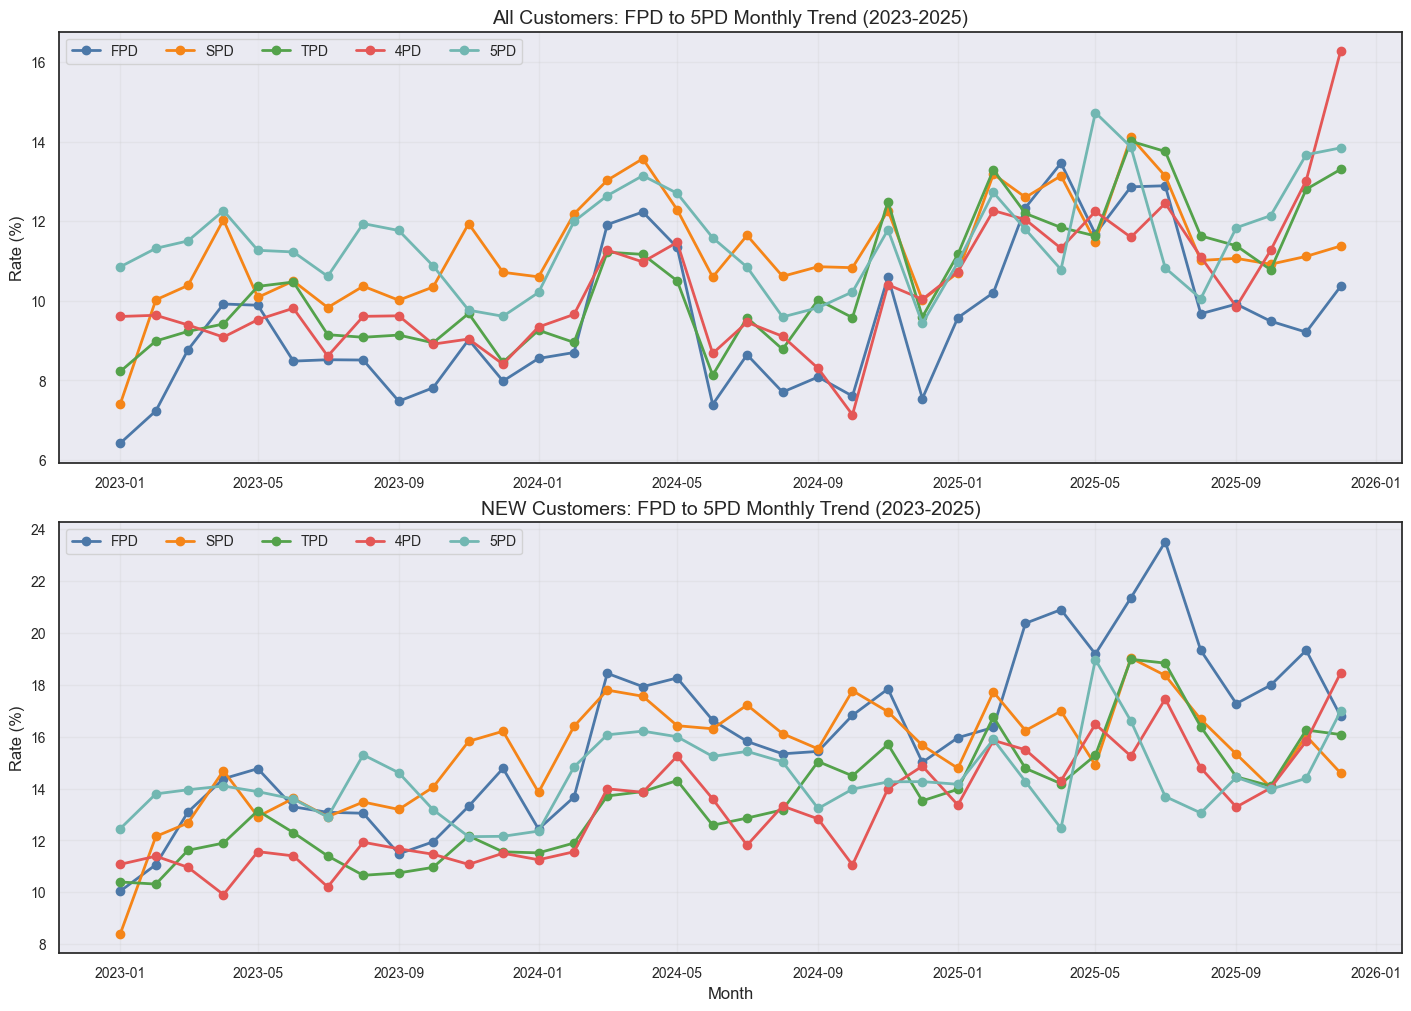

All-customer table (2023-2025):


,AppYear,AppMonth,CohortLoans,FPD_Rate,SPD_Rate,TPD_Rate,PD4_Rate,PD5_Rate
1,2023,1,4779,0.064239,0.074129,0.082265,0.096064,0.108554
15,2023,2,4714,0.072338,0.100244,0.089901,0.096364,0.113187
30,2023,3,5658,0.087663,0.103857,0.092313,0.093935,0.115052
9,2023,4,5706,0.099194,0.120373,0.094173,0.090876,0.122658
4,2023,5,6310,0.098891,0.100869,0.103631,0.095254,0.112692
6,2023,6,6070,0.084843,0.104974,0.104727,0.098131,0.112281
34,2023,7,5963,0.085192,0.098318,0.091483,0.086097,0.106160
32,2023,8,6591,0.085116,0.103671,0.090839,0.096096,0.119408
18,2023,9,5497,0.074768,0.100153,0.091391,0.096231,0.117672
2,2023,10,6014,0.078151,0.103472,0.089451,0.089109,0.108779


NEW-customer table (2023-2025):


,AppYear,AppMonth,CohortLoans,FPD_Rate,SPD_Rate,TPD_Rate,PD4_Rate,PD5_Rate
19,2023,1,2210,0.100452,0.084029,0.103954,0.110776,0.124558
30,2023,2,2269,0.110621,0.121532,0.103148,0.113904,0.137931
14,2023,3,2719,0.130930,0.126688,0.116187,0.109635,0.139517
23,2023,4,2970,0.143771,0.146878,0.118957,0.099105,0.140969
7,2023,5,3122,0.147662,0.129167,0.131434,0.115658,0.138793
27,2023,6,2821,0.132932,0.136183,0.122995,0.114019,0.135965
18,2023,7,2851,0.130831,0.129117,0.113998,0.102041,0.129009
16,2023,8,3112,0.130463,0.134791,0.106526,0.119287,0.152988
34,2023,9,2526,0.114806,0.131938,0.107457,0.116758,0.146086
6,2023,10,2880,0.119444,0.140503,0.109589,0.114654,0.131805


In [10]:
from util.plot_style import apply_plot_style, PLOT_PALETTE
from sqlalchemy import text

# Load both temp tables in a single SQL session (faster and avoids temp-table scope issues).
with engine.connect() as conn:
    conn.exec_driver_sql(setup_sql)

    monthly_exists = conn.execute(text("SELECT OBJECT_ID('tempdb..#monthly_summary')")).scalar()
    monthly_new_exists = conn.execute(text("SELECT OBJECT_ID('tempdb..#monthly_summary_new')")).scalar()
    if monthly_exists is None or monthly_new_exists is None:
        raise ValueError('Temp tables #monthly_summary / #monthly_summary_new were not created. Check end of SQL script.')

    monthly_all = pd.read_sql_query(text('SELECT * FROM #monthly_summary'), conn)
    monthly_new = pd.read_sql_query(text('SELECT * FROM #monthly_summary_new'), conn)

# Keep 2023-2025 trend window.
def prep_monthly(df):
    out = df.copy()
    out['AppYear'] = pd.to_numeric(out['AppYear'], errors='coerce')
    out['AppMonth'] = pd.to_numeric(out['AppMonth'], errors='coerce')
    out = out[out['AppYear'].between(2023, 2025)].copy()
    out['month_dt'] = pd.to_datetime(
        out['AppYear'].astype('Int64').astype(str) + '-' + out['AppMonth'].astype('Int64').astype(str).str.zfill(2) + '-01',
        errors='coerce'
    )
    out = out.sort_values(['AppYear', 'AppMonth'])
    return out

monthly_all = prep_monthly(monthly_all)
monthly_new = prep_monthly(monthly_new)

rate_cols = ['FPD_Rate', 'SPD_Rate', 'TPD_Rate', 'PD4_Rate', 'PD5_Rate']
rate_labels = ['FPD', 'SPD', 'TPD', '4PD', '5PD']

apply_plot_style(style='white', axes_grid=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

# All-customer trend.
for i, (col, label) in enumerate(zip(rate_cols, rate_labels)):
    if col in monthly_all.columns:
        axes[0].plot(monthly_all['month_dt'], monthly_all[col] * 100.0, marker='o', linewidth=2, label=label, color=PLOT_PALETTE[i % len(PLOT_PALETTE)])
axes[0].set_title('All Customers: FPD to 5PD Monthly Trend (2023-2025)')
axes[0].set_ylabel('Rate (%)')
axes[0].grid(alpha=0.25)
axes[0].legend(loc='best', ncol=5)

# NEW-customer trend.
for i, (col, label) in enumerate(zip(rate_cols, rate_labels)):
    if col in monthly_new.columns:
        axes[1].plot(monthly_new['month_dt'], monthly_new[col] * 100.0, marker='o', linewidth=2, label=label, color=PLOT_PALETTE[i % len(PLOT_PALETTE)])
axes[1].set_title('NEW Customers: FPD to 5PD Monthly Trend (2023-2025)')
axes[1].set_ylabel('Rate (%)')
axes[1].set_xlabel('Month')
axes[1].grid(alpha=0.25)
axes[1].legend(loc='best', ncol=5)

plt.show()

print('All-customer table (2023-2025):')
display(monthly_all[['AppYear', 'AppMonth', 'CohortLoans'] + [c for c in rate_cols if c in monthly_all.columns]])

print('NEW-customer table (2023-2025):')
display(monthly_new[['AppYear', 'AppMonth', 'CohortLoans'] + [c for c in rate_cols if c in monthly_new.columns]])

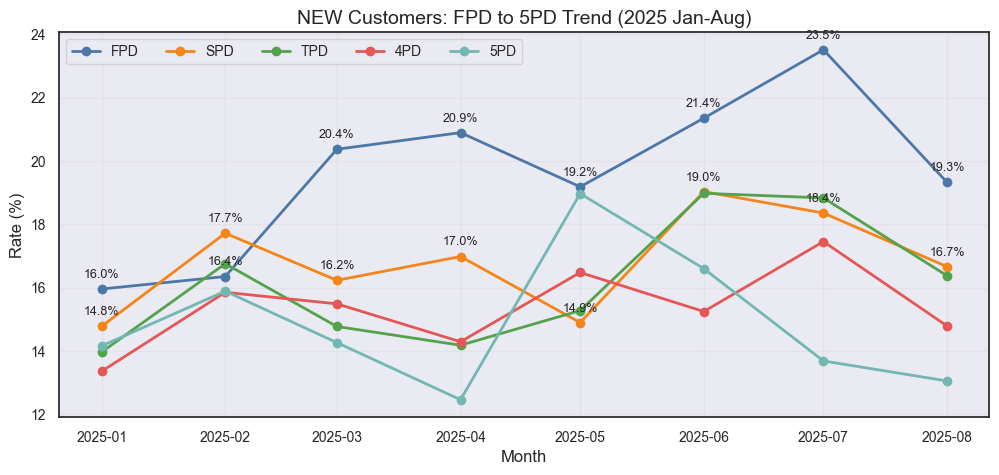

,AppYear,AppMonth,CohortLoans,FPD_Rate,SPD_Rate,TPD_Rate,PD4_Rate,PD5_Rate
2,2025,1,2174,0.159614,0.147821,0.139706,0.133632,0.141640
1,2025,2,2146,0.163560,0.177231,0.167593,0.158573,0.158924
25,2025,3,2204,0.203721,0.162362,0.147779,0.154930,0.142694
10,2025,4,2651,0.208978,0.169869,0.141862,0.142967,0.124654
35,2025,5,2460,0.191870,0.149015,0.152805,0.164826,0.189739
15,2025,6,2201,0.213539,0.190358,0.189833,0.152508,0.166042
17,2025,7,1901,0.235139,0.183599,0.188366,0.174584,0.136905
20,2025,8,1459,0.193283,0.166667,0.163803,0.147937,0.130584


In [11]:
# Quick comparison view: NEW customers, Jan-Aug 2005
from util.plot_style import apply_plot_style, PLOT_PALETTE

apply_plot_style(style='white', axes_grid=False)

compare_year = 2025
compare_month_start = 1
compare_month_end = 8

if 'monthly_new' not in globals():
    raise ValueError("monthly_new not found. Please run Cell 7 first to load monthly summary tables.")

new_compare = monthly_new[
    (monthly_new['AppYear'] == compare_year)
    & (monthly_new['AppMonth'] >= compare_month_start)
    & (monthly_new['AppMonth'] <= compare_month_end)
].copy()

if new_compare.empty:
    print(f'No NEW-customer rows found for {compare_year}-{compare_month_start:02d} to {compare_year}-{compare_month_end:02d}.')
    print('Tip: if you meant 2025, change compare_year = 2025.')
else:
    new_compare = new_compare.sort_values(['AppYear', 'AppMonth'])
    new_compare['month_dt'] = pd.to_datetime(
        new_compare['AppYear'].astype(int).astype(str) + '-'
        + new_compare['AppMonth'].astype(int).astype(str).str.zfill(2) + '-01'
    )

    rate_cols = ['FPD_Rate', 'SPD_Rate', 'TPD_Rate', 'PD4_Rate', 'PD5_Rate']
    rate_labels = ['FPD', 'SPD', 'TPD', '4PD', '5PD']

    plt.figure(figsize=(12, 5))
    for i, (col, label) in enumerate(zip(rate_cols, rate_labels)):
        if col in new_compare.columns:
            y_vals = new_compare[col] * 100.0
            plt.plot(
                new_compare['month_dt'],
                y_vals,
                marker='o',
                linewidth=2,
                label=label,
                color=PLOT_PALETTE[i % len(PLOT_PALETTE)],
            )

            # Label only FPD/SPD points with XX.X% for quick comparison.
            if col in ['FPD_Rate', 'SPD_Rate']:
                for x, y in zip(new_compare['month_dt'], y_vals):
                    if pd.notna(y):
                        plt.annotate(
                            f'{y:.1f}%',
                            (x, y),
                            textcoords='offset points',
                            xytext=(0, 8),
                            ha='center',
                            fontsize=9,
                        )

    plt.title(f'NEW Customers: FPD to 5PD Trend ({compare_year} Jan-Aug)')
    plt.ylabel('Rate (%)')
    plt.xlabel('Month')
    plt.grid(alpha=0.25)
    plt.legend(loc='best', ncol=5)
    plt.show()

    display_cols = ['AppYear', 'AppMonth', 'CohortLoans'] + [c for c in rate_cols if c in new_compare.columns]
    display(new_compare[display_cols])

---

## Waterfall Plot

In [12]:
raw_df['Frequency'].value_counts()

Frequency
B    556974
W    203508
S    127932
M    116073
Name: count, dtype: int64

In [13]:
# Revised matrix with explicit 4-frequency handling (B/W/S/M)
analysis_year = 2025
max_installment = 20
grouping_mode = 'native4'  # 'native4' or 'business3'

required_cols = [
    'LoanID', 'AppYear', 'InstallmentNumber', 'TotalInstallsNumber',
    'CustType', 'Frequency', 'isLoanDefault', 'isArrangementInstall', 'is3rdPartyInstall'
]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns for analysis: {missing}')

base = raw_df.copy()
base['AppYear'] = pd.to_numeric(base['AppYear'], errors='coerce')
base['InstallmentNumber'] = pd.to_numeric(base['InstallmentNumber'], errors='coerce')
base['TotalInstallsNumber'] = pd.to_numeric(base['TotalInstallsNumber'], errors='coerce')
base['isLoanDefault'] = pd.to_numeric(base['isLoanDefault'], errors='coerce').fillna(0).astype(int)
base = base[(base['AppYear'] == analysis_year) & (base['isArrangementInstall'] == 0) & (base['is3rdPartyInstall'] == 0)].copy()

base['CustType_norm'] = base['CustType'].astype(str).str.upper().str.strip()

def _norm_freq(v):
    s = str(v).upper().strip()
    if s in {'W', 'WEEK', 'WEEKLY', '1', '4'}:
        return 'W'
    if s in {'B', 'BIWEEKLY', 'BI-WEEKLY'}:
        return 'B'
    if s in {'S', 'SEMI', 'SEMI-MONTHLY', 'SEMIMONTHLY', '2', '5'}:
        return 'S'
    if s in {'M', 'MONTHLY', '3', '6'}:
        return 'M'
    return np.nan

base['Frequency_norm'] = base['Frequency'].apply(_norm_freq)

if grouping_mode == 'business3':
    freq_group_map = {'W': 'W', 'B': 'W', 'S': 'Semi', 'M': 'M'}
    col_order = [
        ('NEW', 'W'), ('NEW', 'Semi'), ('NEW', 'M'),
        ('RETURN', 'W'), ('RETURN', 'Semi'), ('RETURN', 'M'),
    ]
else:
    freq_group_map = {'W': 'W', 'B': 'B', 'S': 'S', 'M': 'M'}
    col_order = [
        ('NEW', 'W'), ('NEW', 'B'), ('NEW', 'S'), ('NEW', 'M'),
        ('RETURN', 'W'), ('RETURN', 'B'), ('RETURN', 'S'), ('RETURN', 'M'),
    ]

base['Frequency_group'] = base['Frequency_norm'].map(freq_group_map)

print('Raw Frequency distribution in filtered base:')
print(base['Frequency'].astype(str).str.upper().str.strip().value_counts(dropna=False))
print('Normalized Frequency distribution:')
print(base['Frequency_group'].value_counts(dropna=False))

base = base[(base['InstallmentNumber'] >= 1) & (base['InstallmentNumber'] <= max_installment)].copy()
base['eligible_flag'] = (base['TotalInstallsNumber'] >= base['InstallmentNumber']).astype(int)

group_cols = ['InstallmentNumber', 'CustType_norm', 'Frequency_group']

denom = base[base['eligible_flag'] == 1].groupby(group_cols)['LoanID'].nunique().rename('denom')
num = base[(base['eligible_flag'] == 1) & (base['isLoanDefault'] == 1)].groupby(group_cols)['LoanID'].nunique().rename('num')

rates = pd.concat([denom, num], axis=1).fillna(0).reset_index()
rates['rate'] = np.where(rates['denom'] > 0, rates['num'] / rates['denom'], np.nan)

table = (
    rates.pivot_table(index='InstallmentNumber', columns=['CustType_norm', 'Frequency_group'], values='rate', aggfunc='first')
    .reindex(range(1, max_installment + 1))
)

for c in col_order:
    if c not in table.columns:
        table[c] = np.nan
table = table[col_order]

table_pct_display = (table * 100).round(1).copy()
for col in table_pct_display.columns:
    table_pct_display[col] = table_pct_display[col].map(lambda x: '' if pd.isna(x) else f'{x:.1f}%')

print(f'Loan default rate matrix for {analysis_year} (Installments 1-{max_installment})')
print('Numerator: unique loans with isLoanDefault=1 at installment k')
print('Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)')
display(table_pct_display)

Raw Frequency distribution in filtered base:
Frequency
B       141641
W        44955
S        30231
M        22347
NONE         3
Name: count, dtype: int64
Normalized Frequency distribution:
Frequency_group
B      141641
W       44955
S       30231
M       22347
NaN         3
Name: count, dtype: int64
Loan default rate matrix for 2025 (Installments 1-20)
Numerator: unique loans with isLoanDefault=1 at installment k
Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)


CustType_norm        NEW                      RETURN                    
Frequency_group        W      B      S      M      W     B      S      M
InstallmentNumber                                                       
1                  15.3%  20.2%  19.0%  17.5%   3.5%  5.0%   5.1%   5.3%
2                  12.8%  16.6%  17.2%  19.4%   5.1%  7.6%   8.3%  11.3%
3                  12.8%  15.9%  16.7%  19.9%   5.7%  8.1%   8.3%  15.4%
4                  13.0%  15.6%  15.9%  19.5%   5.7%  7.8%   8.6%  16.1%
5                  13.1%  15.5%  15.6%  15.1%   6.6%  8.9%  10.3%  16.9%
6                  11.5%  14.1%  17.2%  15.7%   5.5%  8.0%   9.4%  15.4%
7                   9.4%  12.1%  19.8%  15.6%   4.3%  7.6%  10.6%  16.4%
8                   9.9%  13.9%  14.3%   8.1%   5.0%  7.7%   9.4%  15.5%
9                  10.9%  11.7%  10.7%   8.8%   5.2%  7.4%   7.4%  16.3%
10                  8.3%  10.0%   8.4%   7.9%   3.2%  7.1%   5.9%  14.8%
11                  6.2%   8.3%   9.5%  16.3%   3.8%  6.6%   9.0%  19.1%
12                  5.9%   9.6%  11.7%  25.7%   4.2%  6.6%   5.1%  15.8%
13                  7.6%   9.0%  11.4%  29.3%   3.3%  6.2%   9.6%  34.8%
14                  6.6%   9.3%   9.1%  34.3%   2.1%  5.9%   5.9%  23.1%
15                  7.2%   8.9%   8.6%  15.8%   3.8%  5.1%   8.2%  14.3%
16                  6.6%   6.1%   9.3%   0.0%   3.9%  5.2%   8.3%   0.0%
17                  7.0%   6.6%  10.7%   0.0%   4.2%  6.4%   9.1%   7.7%
18                  3.2%   6.1%   4.7%   0.0%   5.6%  6.3%   3.2%   0.0%
19                  1.0%   5.0%   0.0%   0.0%   2.3%  4.9%   2.4%   0.0%
20                  0.0%   5.9%   0.0%          4.0%  3.0%   0.0%   0.0%

In [14]:
# Business 3 output (W / Semi / M) for 2025 installment default-rate matrix
analysis_year = 2025
max_installment = 20

required_cols = [
    'LoanID', 'AppYear', 'InstallmentNumber', 'TotalInstallsNumber',
    'CustType', 'Frequency', 'isLoanDefault', 'isArrangementInstall', 'is3rdPartyInstall'
]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns for analysis: {missing}')

base = raw_df.copy()
base['AppYear'] = pd.to_numeric(base['AppYear'], errors='coerce')
base['InstallmentNumber'] = pd.to_numeric(base['InstallmentNumber'], errors='coerce')
base['TotalInstallsNumber'] = pd.to_numeric(base['TotalInstallsNumber'], errors='coerce')
base['isLoanDefault'] = pd.to_numeric(base['isLoanDefault'], errors='coerce').fillna(0).astype(int)
base = base[(base['AppYear'] == analysis_year) & (base['isArrangementInstall'] == 0) & (base['is3rdPartyInstall'] == 0)].copy()

base['CustType_norm'] = base['CustType'].astype(str).str.upper().str.strip()

def _norm_freq(v):
    s = str(v).upper().strip()
    if s in {'W', 'WEEK', 'WEEKLY', '1', '4'}:
        return 'W'
    if s in {'B', 'BIWEEKLY', 'BI-WEEKLY'}:
        return 'B'
    if s in {'S', 'SEMI', 'SEMI-MONTHLY', 'SEMIMONTHLY', '2', '5'}:
        return 'S'
    if s in {'M', 'MONTHLY', '3', '6'}:
        return 'M'
    return np.nan

base['Frequency_norm'] = base['Frequency'].apply(_norm_freq)

# Business 3 grouping: B rolls into W
freq_group_map = {'W': 'W', 'B': 'W', 'S': 'Semi', 'M': 'M'}
col_order = [
    ('NEW', 'W'), ('NEW', 'Semi'), ('NEW', 'M'),
    ('RETURN', 'W'), ('RETURN', 'Semi'), ('RETURN', 'M'),
]
base['Frequency_group'] = base['Frequency_norm'].map(freq_group_map)

base = base[(base['InstallmentNumber'] >= 1) & (base['InstallmentNumber'] <= max_installment)].copy()
base['eligible_flag'] = (base['TotalInstallsNumber'] >= base['InstallmentNumber']).astype(int)

group_cols = ['InstallmentNumber', 'CustType_norm', 'Frequency_group']
denom = base[base['eligible_flag'] == 1].groupby(group_cols)['LoanID'].nunique().rename('denom')
num = base[(base['eligible_flag'] == 1) & (base['isLoanDefault'] == 1)].groupby(group_cols)['LoanID'].nunique().rename('num')

rates = pd.concat([denom, num], axis=1).fillna(0).reset_index()
rates['rate'] = np.where(rates['denom'] > 0, rates['num'] / rates['denom'], np.nan)

table = (
    rates.pivot_table(index='InstallmentNumber', columns=['CustType_norm', 'Frequency_group'], values='rate', aggfunc='first')
    .reindex(range(1, max_installment + 1))
)

for c in col_order:
    if c not in table.columns:
        table[c] = np.nan
table = table[col_order]

table_pct_display = (table * 100).round(1).copy()
for col in table_pct_display.columns:
    table_pct_display[col] = table_pct_display[col].map(lambda x: '' if pd.isna(x) else f'{x:.1f}%')

print(f'Business 3 loan default rate matrix for {analysis_year} (Installments 1-{max_installment})')
print('Grouping: B + W -> W, S -> Semi, M -> M')
print('Numerator: unique loans with isLoanDefault=1 at installment k')
print('Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)')
display(table_pct_display)

Business 3 loan default rate matrix for 2025 (Installments 1-20)
Grouping: B + W -> W, S -> Semi, M -> M
Numerator: unique loans with isLoanDefault=1 at installment k
Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)


CustType_norm        NEW               RETURN              
Frequency_group        W   Semi      M      W   Semi      M
InstallmentNumber                                          
1                  19.3%  19.0%  17.5%   4.7%   5.1%   5.3%
2                  15.8%  17.2%  19.4%   7.0%   8.3%  11.3%
3                  15.3%  16.7%  19.9%   7.5%   8.3%  15.4%
4                  15.0%  15.9%  19.5%   7.3%   8.6%  16.1%
5                  14.9%  15.6%  15.1%   8.3%  10.3%  16.9%
6                  13.5%  17.2%  15.7%   7.3%   9.4%  15.4%
7                  11.4%  19.8%  15.6%   6.6%  10.6%  16.4%
8                  12.9%  14.3%   8.1%   6.9%   9.4%  15.5%
9                  11.5%  10.7%   8.8%   6.7%   7.4%  16.3%
10                  9.5%   8.4%   7.9%   5.8%   5.9%  14.8%
11                  7.7%   9.5%  16.3%   5.7%   9.0%  19.1%
12                  8.6%  11.7%  25.7%   5.8%   5.1%  15.8%
13                  8.6%  11.4%  29.3%   5.2%   9.6%  34.8%
14                  8.5%   9.1%  34.3%   4.6%   5.9%  23.1%
15                  8.4%   8.6%  15.8%   4.6%   8.2%  14.3%
16                  6.3%   9.3%   0.0%   4.7%   8.3%   0.0%
17                  6.7%  10.7%   0.0%   5.6%   9.1%   7.7%
18                  5.2%   4.7%   0.0%   6.0%   3.2%   0.0%
19                  3.5%   0.0%   0.0%   3.8%   2.4%   0.0%
20                  1.9%   0.0%          3.4%   0.0%   0.0%

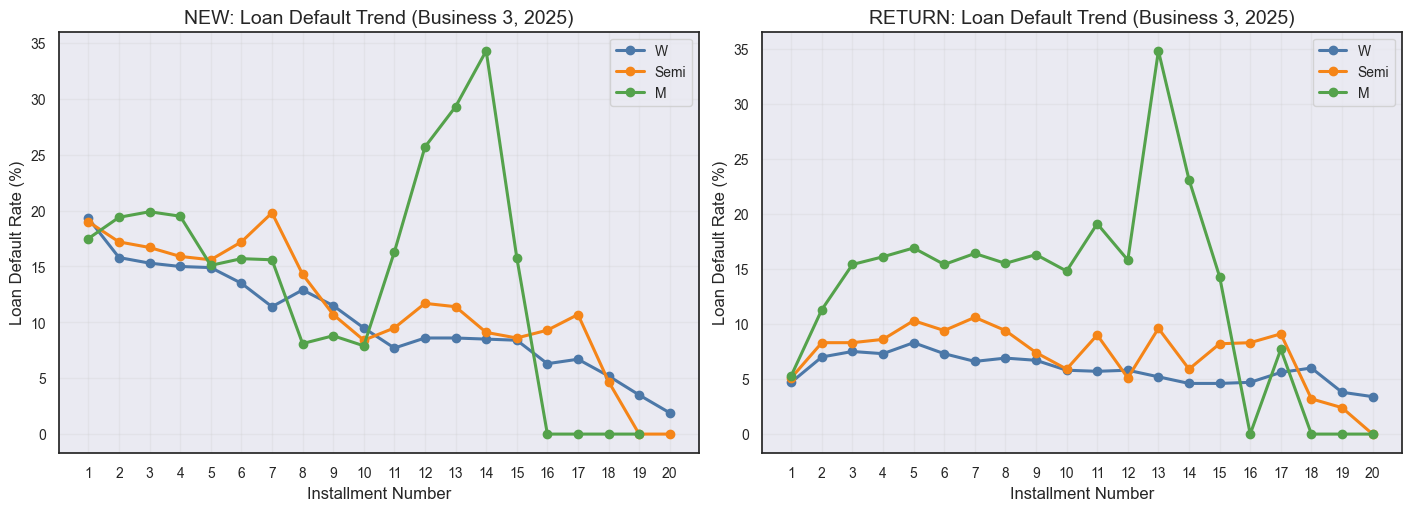

CustType_norm        NEW               RETURN              
Frequency_group        W   Semi      M      W   Semi      M
InstallmentNumber                                          
1                  19.3%  19.0%  17.5%   4.7%   5.1%   5.3%
2                  15.8%  17.2%  19.4%   7.0%   8.3%  11.3%
3                  15.3%  16.7%  19.9%   7.5%   8.3%  15.4%
4                  15.0%  15.9%  19.5%   7.3%   8.6%  16.1%
5                  14.9%  15.6%  15.1%   8.3%  10.3%  16.9%
6                  13.5%  17.2%  15.7%   7.3%   9.4%  15.4%
7                  11.4%  19.8%  15.6%   6.6%  10.6%  16.4%
8                  12.9%  14.3%   8.1%   6.9%   9.4%  15.5%
9                  11.5%  10.7%   8.8%   6.7%   7.4%  16.3%
10                  9.5%   8.4%   7.9%   5.8%   5.9%  14.8%
11                  7.7%   9.5%  16.3%   5.7%   9.0%  19.1%
12                  8.6%  11.7%  25.7%   5.8%   5.1%  15.8%
13                  8.6%  11.4%  29.3%   5.2%   9.6%  34.8%
14                  8.5%   9.1%  34.3%   4.6%   5.9%  23.1%
15                  8.4%   8.6%  15.8%   4.6%   8.2%  14.3%
16                  6.3%   9.3%   0.0%   4.7%   8.3%   0.0%
17                  6.7%  10.7%   0.0%   5.6%   9.1%   7.7%
18                  5.2%   4.7%   0.0%   6.0%   3.2%   0.0%
19                  3.5%   0.0%   0.0%   3.8%   2.4%   0.0%
20                  1.9%   0.0%          3.4%   0.0%   0.0%

---

## Paid Off Rate

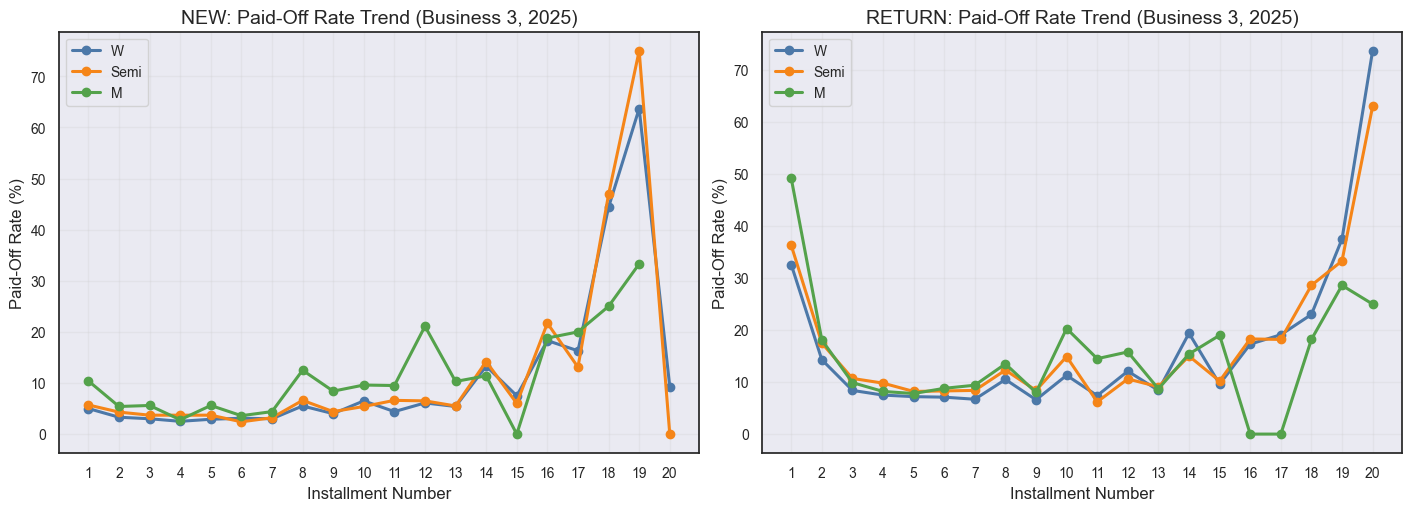

Business 3 paid-off rate matrix for 2025 (Installments 1-20)
Numerator: unique loans with LoanPaidOffThisInstall=1 at installment k
Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)


CustType_norm        NEW               RETURN              
Frequency_group        W   Semi      M      W   Semi      M
InstallmentNumber                                          
1                   5.0%   5.7%  10.4%  32.6%  36.3%  49.2%
2                   3.3%   4.3%   5.4%  14.3%  17.5%  18.1%
3                   3.0%   3.7%   5.6%   8.4%  10.7%   9.9%
4                   2.5%   3.7%   2.8%   7.5%   9.8%   8.2%
5                   2.9%   3.7%   5.6%   7.2%   8.2%   7.8%
6                   3.1%   2.4%   3.6%   7.1%   8.3%   8.8%
7                   3.0%   3.2%   4.4%   6.7%   8.4%   9.4%
8                   5.5%   6.6%  12.5%  10.5%  12.3%  13.5%
9                   4.0%   4.4%   8.4%   6.6%   8.4%   8.0%
10                  6.5%   5.4%   9.6%  11.3%  14.9%  20.3%
11                  4.4%   6.6%   9.5%   7.4%   6.2%  14.5%
12                  6.1%   6.5%  21.1%  12.1%  10.6%  15.8%
13                  5.4%   5.5%  10.3%   8.4%   9.1%   8.7%
14                 13.3%  14.2%  11.4%  19.4%  15.0%  15.4%
15                  7.5%   6.0%   0.0%   9.6%  10.2%  19.0%
16                 18.3%  21.7%  18.8%  17.3%  18.3%   0.0%
17                 16.3%  13.1%  20.0%  19.1%  18.2%   0.0%
18                 44.4%  46.9%  25.0%  23.0%  28.6%  18.2%
19                 63.7%  75.0%  33.3%  37.5%  33.3%  28.6%
20                  9.3%   0.0%         73.7%  63.0%  25.0%

In [17]:
# Business 3 paid-off rate matrix + trend plot (cell 17/17)
# Numerator: LoanPaidOffThisInstall = 1 at installment k
# Denominator: eligible loans at installment k (TotalInstallsNumber >= k)

from util.plot_style import apply_plot_style, PLOT_PALETTE

analysis_year = 2025
max_installment = 20

required_cols = [
    'LoanID', 'AppYear', 'InstallmentNumber', 'TotalInstallsNumber',
    'CustType', 'Frequency', 'LoanPaidOffThisInstall', 'isArrangementInstall', 'is3rdPartyInstall'
]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns for paid-off analysis: {missing}')

base = raw_df.copy()
base['AppYear'] = pd.to_numeric(base['AppYear'], errors='coerce')
base['InstallmentNumber'] = pd.to_numeric(base['InstallmentNumber'], errors='coerce')
base['TotalInstallsNumber'] = pd.to_numeric(base['TotalInstallsNumber'], errors='coerce')
base['LoanPaidOffThisInstall'] = pd.to_numeric(base['LoanPaidOffThisInstall'], errors='coerce').fillna(0).astype(int)

base = base[
    (base['AppYear'] == analysis_year)
    & (base['isArrangementInstall'] == 0)
    & (base['is3rdPartyInstall'] == 0)
    & (base['InstallmentNumber'] >= 1)
    & (base['InstallmentNumber'] <= max_installment)
].copy()

base['CustType_norm'] = base['CustType'].astype(str).str.upper().str.strip()

# Business 3 grouping: B + W -> W, S -> Semi, M -> M
freq_map = {
    'W': 'W', 'WEEK': 'W', 'WEEKLY': 'W', '1': 'W', '4': 'W',
    'B': 'W', 'BIWEEKLY': 'W', 'BI-WEEKLY': 'W',
    'S': 'Semi', 'SEMI': 'Semi', 'SEMI-MONTHLY': 'Semi', 'SEMIMONTHLY': 'Semi', '2': 'Semi', '5': 'Semi',
    'M': 'M', 'MONTHLY': 'M', '3': 'M', '6': 'M',
}
base['Frequency_group'] = base['Frequency'].astype(str).str.upper().str.strip().map(freq_map)

# Eligible denominator per installment k, matching notebook/sql method.
base['eligible_flag'] = (base['TotalInstallsNumber'] >= base['InstallmentNumber']).astype(int)

group_cols = ['InstallmentNumber', 'CustType_norm', 'Frequency_group']

denom = base[base['eligible_flag'] == 1].groupby(group_cols)['LoanID'].nunique().rename('denom')
num = base[(base['eligible_flag'] == 1) & (base['LoanPaidOffThisInstall'] == 1)].groupby(group_cols)['LoanID'].nunique().rename('num')

rates = pd.concat([denom, num], axis=1).fillna(0).reset_index()
rates['rate'] = np.where(rates['denom'] > 0, rates['num'] / rates['denom'], np.nan)

col_order = [
    ('NEW', 'W'), ('NEW', 'Semi'), ('NEW', 'M'),
    ('RETURN', 'W'), ('RETURN', 'Semi'), ('RETURN', 'M'),
]

paidoff_biz3 = (
    rates.pivot_table(index='InstallmentNumber', columns=['CustType_norm', 'Frequency_group'], values='rate', aggfunc='first')
    .reindex(range(1, max_installment + 1))
)
for c in col_order:
    if c not in paidoff_biz3.columns:
        paidoff_biz3[c] = np.nan
paidoff_biz3 = paidoff_biz3[col_order]

paidoff_biz3_pct = (paidoff_biz3 * 100).round(1)

# Presentation-ready trend plots.
apply_plot_style(style='white', axes_grid=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
series_style = [('W', PLOT_PALETTE[0]), ('Semi', PLOT_PALETTE[1]), ('M', PLOT_PALETTE[2])]

for cust, ax in [('NEW', axes[0]), ('RETURN', axes[1])]:
    for freq, color in series_style:
        col = (cust, freq)
        y = pd.to_numeric(paidoff_biz3_pct[col], errors='coerce')
        ax.plot(paidoff_biz3_pct.index, y, marker='o', linewidth=2.2, label=freq, color=color)

    ax.set_title(f'{cust}: Paid-Off Rate Trend (Business 3, {analysis_year})')
    ax.set_xlabel('Installment Number')
    ax.set_ylabel('Paid-Off Rate (%)')
    ax.set_xticks(list(range(1, max_installment + 1)))
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

plt.show()

paidoff_display = paidoff_biz3_pct.copy()
for col in paidoff_display.columns:
    paidoff_display[col] = paidoff_display[col].map(lambda x: '' if pd.isna(x) else f'{x:.1f}%')

print(f'Business 3 paid-off rate matrix for {analysis_year} (Installments 1-{max_installment})')
print('Numerator: unique loans with LoanPaidOffThisInstall=1 at installment k')
print('Denominator: unique eligible loans at installment k (TotalInstallsNumber >= k)')
display(paidoff_display)

In [18]:
# Sanity check counts (pandas equivalent of SQL check)
# Uses #t17_combined-loaded raw_df with same cohort filter:
# isArrangementInstall = 0 and is3rdPartyInstall = 0

required_cols = [
    'AppYear', 'AppMonth', 'LoanID', 'InstallmentNumber', 'TotalInstallsNumber',
    'isLoanDefault', 'LoanPaidOffThisInstall', 'isArrangementInstall', 'is3rdPartyInstall'
]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns for sanity check: {missing}')

chk = raw_df.copy()
chk['AppYear'] = pd.to_numeric(chk['AppYear'], errors='coerce')
chk['AppMonth'] = pd.to_numeric(chk['AppMonth'], errors='coerce')
chk['InstallmentNumber'] = pd.to_numeric(chk['InstallmentNumber'], errors='coerce')
chk['TotalInstallsNumber'] = pd.to_numeric(chk['TotalInstallsNumber'], errors='coerce')
chk['isLoanDefault'] = pd.to_numeric(chk['isLoanDefault'], errors='coerce').fillna(0).astype(int)
chk['LoanPaidOffThisInstall'] = pd.to_numeric(chk['LoanPaidOffThisInstall'], errors='coerce').fillna(0).astype(int)

chk = chk[(chk['isArrangementInstall'] == 0) & (chk['is3rdPartyInstall'] == 0)].copy()

# Boolean flags matching SQL CASE expressions.
chk['is_inst_1'] = ((chk['InstallmentNumber'] == 1) & (chk['TotalInstallsNumber'] >= 1)).astype(int)
chk['is_inst_2'] = ((chk['InstallmentNumber'] == 2) & (chk['TotalInstallsNumber'] >= 2)).astype(int)
chk['fpd_num_flag'] = ((chk['InstallmentNumber'] == 1) & (chk['isLoanDefault'] == 1)).astype(int)
chk['first_paidoff_flag'] = ((chk['InstallmentNumber'] == 1) & (chk['LoanPaidOffThisInstall'] == 1)).astype(int)

grp = chk.groupby(['AppYear', 'AppMonth'], dropna=False)

sanity_counts = grp.agg(
    CohortLoans=('LoanID', lambda s: s.nunique()),
    FPD_Denom=('is_inst_1', 'sum'),
    FPD_Num=('fpd_num_flag', 'sum'),
    FirstInstallPaidOff=('first_paidoff_flag', 'sum'),
    SPD_Denom=('is_inst_2', 'sum'),
).reset_index()

sanity_counts['ImpliedSPD_Denom'] = (
    sanity_counts['FPD_Denom']
    - sanity_counts['FPD_Num']
    - sanity_counts['FirstInstallPaidOff']
)

sanity_counts['Variance'] = sanity_counts['SPD_Denom'] - sanity_counts['ImpliedSPD_Denom']

sanity_counts = sanity_counts.sort_values(['AppYear', 'AppMonth']).reset_index(drop=True)

print('Sanity check counts by AppYear/AppMonth:')
display(sanity_counts)

print('Variance summary (should be near zero if flow reconciles):')
print(sanity_counts['Variance'].describe())

Sanity check counts by AppYear/AppMonth:


,AppYear,AppMonth,CohortLoans,FPD_Denom,FPD_Num,FirstInstallPaidOff,SPD_Denom,ImpliedSPD_Denom,Variance
0,2023,1,4779,4779,307,1086,3386,3386,0
1,2023,2,4714,4714,341,1101,3272,3272,0
2,2023,3,5658,5658,496,1195,3967,3967,0
3,2023,4,5706,5706,566,1169,3971,3971,0
4,2023,5,6310,6310,624,1314,4372,4372,0
5,2023,6,6070,6070,515,1192,4363,4363,0
6,2023,7,5963,5963,508,1234,4221,4221,0
7,2023,8,6591,6591,561,1236,4794,4794,0
8,2023,9,5497,5497,411,1162,3924,3924,0
9,2023,10,6014,6014,470,1195,4349,4349,0


Variance summary (should be near zero if flow reconciles):
count      40.000000
mean      -38.500000
std       176.665844
min     -1005.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Variance, dtype: float64


In [20]:
# Overall paid-off rate metrics by installment (no dimensions)
# Count-based table using same eligible denominator logic as SQL/notebook.

analysis_year = 2025
max_installment = 20

required_cols = [
    'AppYear', 'LoanID', 'InstallmentNumber', 'TotalInstallsNumber',
    'CustType', 'LoanPaidOffThisInstall', 'isArrangementInstall', 'is3rdPartyInstall'
]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns for paid-off metrics: {missing}')

po = raw_df.copy()
po['AppYear'] = pd.to_numeric(po['AppYear'], errors='coerce')
po['InstallmentNumber'] = pd.to_numeric(po['InstallmentNumber'], errors='coerce')
po['TotalInstallsNumber'] = pd.to_numeric(po['TotalInstallsNumber'], errors='coerce')
po['LoanPaidOffThisInstall'] = pd.to_numeric(po['LoanPaidOffThisInstall'], errors='coerce').fillna(0).astype(int)

po['CustType_norm'] = po['CustType'].astype(str).str.upper().str.strip()

po = po[
    (po['AppYear'] == analysis_year)
    & (po['CustType_norm'] == 'NEW')
    & (po['isArrangementInstall'] == 0)
    & (po['is3rdPartyInstall'] == 0)
    & (po['InstallmentNumber'] >= 1)
    & (po['InstallmentNumber'] <= max_installment)
].copy()

# Eligible denominator for installment k: TotalInstallsNumber >= k
po['eligible_flag'] = (po['TotalInstallsNumber'] >= po['InstallmentNumber']).astype(int)
po['paidoff_flag'] = ((po['eligible_flag'] == 1) & (po['LoanPaidOffThisInstall'] == 1)).astype(int)

overall_paidoff_metrics = (
    po.groupby('InstallmentNumber', as_index=False)
    .agg(
        eligible_loan_count=('eligible_flag', 'sum'),
        paidoff_loan_count=('paidoff_flag', 'sum')
    )
    .sort_values('InstallmentNumber')
)

overall_paidoff_metrics['paidoff_rate'] = np.where(
    overall_paidoff_metrics['eligible_loan_count'] > 0,
    overall_paidoff_metrics['paidoff_loan_count'] / overall_paidoff_metrics['eligible_loan_count'],
    np.nan,
)
overall_paidoff_metrics['paidoff_rate_pct'] = (overall_paidoff_metrics['paidoff_rate'] * 100).round(2)

print(f'Overall paid-off metrics table ({analysis_year}, NEW only), installments 1-{max_installment}')
print('Denominator: eligible_loan_count = SUM(InstallmentNumber=k and TotalInstallsNumber>=k)')
print('Numerator: paidoff_loan_count = SUM(InstallmentNumber=k and LoanPaidOffThisInstall=1)')

display(overall_paidoff_metrics)

Overall paid-off metrics table (2025, NEW only), installments 1-20
Denominator: eligible_loan_count = SUM(InstallmentNumber=k and TotalInstallsNumber>=k)
Numerator: paidoff_loan_count = SUM(InstallmentNumber=k and LoanPaidOffThisInstall=1)


,InstallmentNumber,eligible_loan_count,paidoff_loan_count,paidoff_rate,paidoff_rate_pct
0,1,22975,1269,0.055234,5.52
1,2,17314,623,0.035982,3.60
2,3,13870,455,0.032805,3.28
3,4,11225,302,0.026904,2.69
4,5,9194,288,0.031325,3.13
5,6,7524,226,0.030037,3.00
6,7,6232,194,0.031130,3.11
7,8,5246,316,0.060236,6.02
8,9,4256,182,0.042763,4.28
9,10,3592,235,0.065423,6.54
